In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

diabites = pd.read_csv("diabetes.csv")

diabites.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [13]:
print("Number of rows and columns:")
print(diabites.shape)

Number of rows and columns:
(768, 9)


In [14]:
print("Column names:")
print(diabites.columns)

Column names:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')


In [15]:
print("Data types:")
print(diabites.dtypes)

Data types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


In [16]:
print("Missing values:")
print(diabites.isnull().sum())

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:

columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print(diabites[columns].eq(0).sum())

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [18]:
for column in columns:
    diabites[column] = diabites[column].replace(0, np.nan)

In [20]:
print(diabites.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [21]:
for column in columns:
    diabites[column] = diabites[column].fillna(diabites[column].median())

In [22]:
print(diabites.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [23]:
print("Number of duplicate records:")
print(diabites.duplicated().sum())

Number of duplicate records:
0


In [24]:
diabites = diabites.drop_duplicates()

print("Shape after removing duplicates:")
print(diabites.shape)

Shape after removing duplicates:
(768, 9)


In [25]:
print("Descriptive Statistics:")
print(diabites.describe())

Descriptive Statistics:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  121.656250      72.386719      29.108073  140.671875   
std       3.369578   30.438286      12.096642       8.791221   86.383060   
min       0.000000   44.000000      24.000000       7.000000   14.000000   
25%       1.000000   99.750000      64.000000      25.000000  121.500000   
50%       3.000000  117.000000      72.000000      29.000000  125.000000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    32.455208                  0.471876   33.240885    0.348958  
std      6.875177                  0.331329   11.760232    0.476951  
min     18.

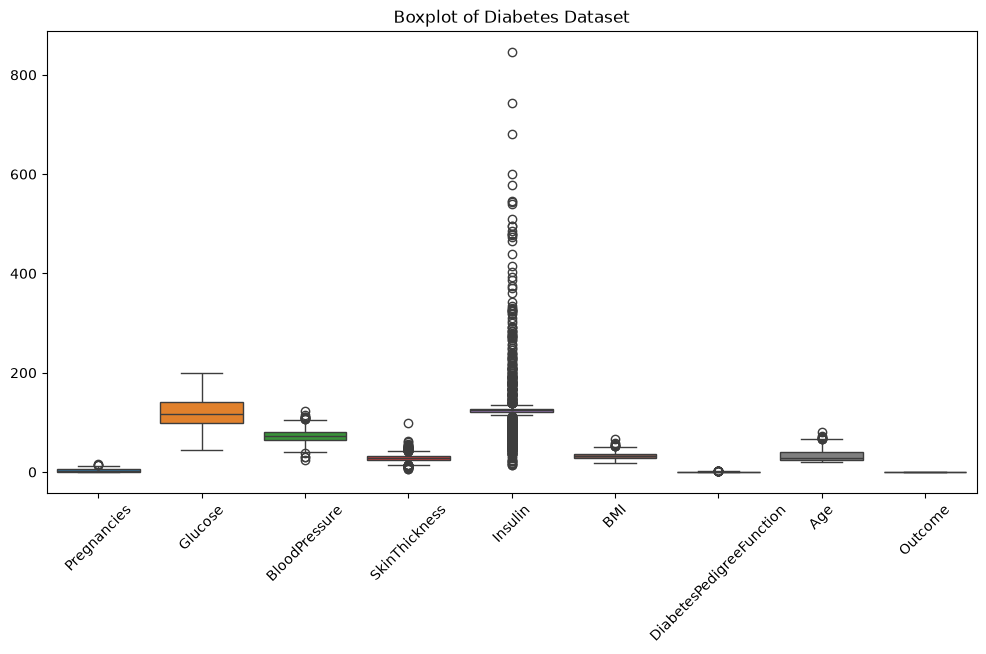

In [26]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=diabites)

plt.xticks(rotation=45)
plt.title("Boxplot of Diabetes Dataset")
plt.show()

In [28]:
numerical_columns = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age'
]

for column in numerical_columns:

    Q1 = diabites[column].quantile(0.25)
    Q3 = diabites[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    # Cap outliers
    diabites[column] = diabites[column].clip(
        lower=lower_limit,
        upper=upper_limit
    )

print("Outliers handled using IQR capping.")

Outliers handled using IQR capping.


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

diabites_scaled = diabites.copy()

diabites_scaled[numerical_columns] = scaler.fit_transform(
    diabites_scaled[numerical_columns]
)

print("Feature scaling completed.")
print(diabites_scaled.head())

Feature scaling completed.
   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0     0.647150  0.866045      -0.030632       0.824667  0.039062  0.181092   
1    -0.848970 -1.205066      -0.543914       0.017945  0.039062 -0.869465   
2     1.245598  2.016662      -0.715008       0.017945  0.039062 -1.364728   
3    -0.848970 -1.073567      -0.543914      -0.788777 -1.494110 -0.644346   
4    -1.148194  0.504422      -2.768136       0.824667  1.414175  1.606849   

   DiabetesPedigreeFunction       Age  Outcome  
0                  0.588927  1.445691        1  
1                 -0.378101 -0.189304        0  
2                  0.746595 -0.103252        1  
3                 -1.022787 -1.049828        0  
4                  2.596563 -0.017199        1  


In [30]:
X = diabites_scaled.drop('Outcome', axis=1)
y = diabites_scaled['Outcome']

print("Input Features (X):")
print(X.head())

print("\nTarget Variable (y):")
print(y.head())

Input Features (X):
   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0     0.647150  0.866045      -0.030632       0.824667  0.039062  0.181092   
1    -0.848970 -1.205066      -0.543914       0.017945  0.039062 -0.869465   
2     1.245598  2.016662      -0.715008       0.017945  0.039062 -1.364728   
3    -0.848970 -1.073567      -0.543914      -0.788777 -1.494110 -0.644346   
4    -1.148194  0.504422      -2.768136       0.824667  1.414175  1.606849   

   DiabetesPedigreeFunction       Age  
0                  0.588927  1.445691  
1                 -0.378101 -0.189304  
2                  0.746595 -0.103252  
3                 -1.022787 -1.049828  
4                  2.596563 -0.017199  

Target Variable (y):
0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (614, 8)
Testing data : (154, 8)


In [32]:
print("Final Preprocessed Dataset:")
print(X_train.head())

Final Preprocessed Dataset:
     Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
353    -0.848970 -1.040692      -0.886102      -1.931634 -1.494110 -0.779418   
711     0.347926  0.142800       0.482650      -0.250963 -1.494110 -0.419226   
373    -0.549746 -0.547570      -1.228290       1.496935 -1.494110  0.376196   
46     -0.848970  0.800295      -1.399384       0.017945  0.039062 -0.404218   
682    -1.148194 -0.876318      -0.715008       1.362481 -1.494110  1.831968   

     DiabetesPedigreeFunction       Age  
353                  0.424252 -0.791671  
711                 -0.069773  0.585167  
373                 -0.819571 -0.705618  
46                   0.368192 -0.361409  
682                 -0.325546 -0.963775  


In [33]:
print("\nTraining Target:")
print(y_train.head())


Training Target:
353    0
711    0
373    0
46     0
682    0
Name: Outcome, dtype: int64


In [34]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (614, 8)
X_test : (154, 8)
y_train: (614,)
y_test : (154,)


--- Core Metrics ---
Precision: 0.90 (When it predicts 'Sick', it is right 90% of the time)
Recall:    0.86 (Out of all actually 'Sick' people, it found 86%)

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.92      0.89       130
           1       0.90      0.86      0.88       120

    accuracy                           0.89       250
   macro avg       0.89      0.89      0.89       250
weighted avg       0.89      0.89      0.89       250



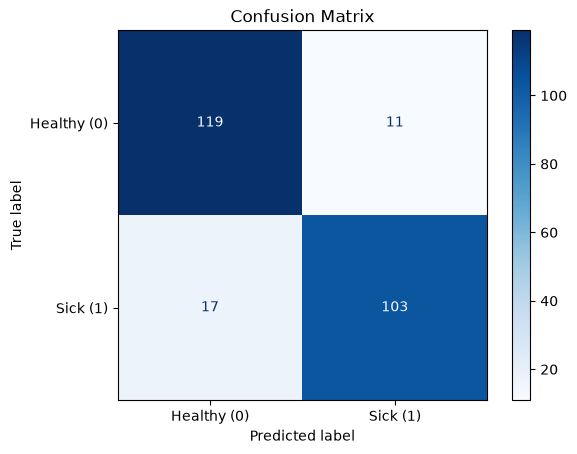

In [1]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Generate a synthetic dataset (e.g., predicting a disease: 1 = Sick, 0 = Healthy)
X, y = make_classification(n_samples=1000, n_features=4, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 2. Train the model
model = LogisticRegression()
model.fit(X_train, y_train)

# 3. Make predictions on the test set
y_pred = model.predict(X_test)

# 4. Calculate Evaluation Metrics
cm = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("--- Core Metrics ---")
print(f"Precision: {precision:.2f} (When it predicts 'Sick', it is right {precision*100:.0f}% of the time)")
print(f"Recall:    {recall:.2f} (Out of all actually 'Sick' people, it found {recall*100:.0f}%)\n")

print("--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))

# 5. Visualize the Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy (0)', 'Sick (1)'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()